# What is imbalance classification? 
Imbalanced Data is an important part of machine learning.
Imbalanced data is the number of observations is not the same for all the classes in a classification data set. 

Imbalance classification is also called rare event modeling. When the target label for a classification modeling dataset is highly imbalanced, we call the minority event to be a rare event. In real-life applications, we face many challenges where we only have uneven data representations in which the minority class is usually the more important one and hence we require methods to improve its recognition rates. This issue poses a serious challenge to predictive modeling because learning algorithms will be biased towards the majority class. 

Important day-to-day tasks in our lives such as preventing malicious attacks, detecting life-threatening diseases, or handling rare cases in monitoring systems face extreme class imbalance with ratios ranging from 1:1000 up to 1:5000 and one must design intelligent systems that can adjust and overcome such extreme bias.

Let's get started!

# Oversampling And Under-Sampling Methods For Imbalanced Classification

*   Random Oversampling
*   SMOTE (Synthetic Minority Oversampling Technique)
*   Random Under-Sampling
*   Near Miss Under-Sampling

# Step 1: Install And Import Libraries

We will use a library called imbalanced-learn to handle imbalanced datasets, so let's install the library first.

In [1]:
pip install -U imbalanced-learn

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 199 kB 14.5 MB/s 
     |████████████████████████████████| 199 kB 18.1 MB/s 
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.8.1
    Uninstalling imbalanced-learn-0.8.1:
      Successfully uninstalled imbalanced-learn-0.8.1


Now let's import the Python libraries.

In [3]:
# Creating the modeling dataset
from sklearn.datasets import make_classification

# Data processing
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model and performance
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Over sampling and under sampling
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler, NearMiss
from collections import Counter

# Step 2: Create Imbalanced Dataset

Using `make_classification` from the sklearn library, we created an imbalanced dataset with two classes. The minority class is 0.5% of the dataset. I made two features to predict which type each data point belongs to.

In [4]:
# Create an imbalanced dataset
X, y = make_classification(n_samples=100000, n_features=2, n_informative=2,
                           n_redundant=0, n_repeated=0, n_classes=2,
                           n_clusters_per_class=1,
                           weights=[0.995, 0.005],
                           class_sep=0.5, random_state=0)

# Convert the data from numpy array to a pandas dataframe
df = pd.DataFrame({'feature1': X[:, 0], 'feature2': X[:, 1], 'target': y})

# Check the target distribution
df['target'].value_counts(normalize = True)

0    0.9897
1    0.0103
Name: target, dtype: float64

In [5]:
df

,feature1,feature2,target
0,1.236497,0.579272,0
1,-0.188720,-0.022001,0
2,-0.653844,0.794309,0
3,0.005572,0.593370,0
4,0.482573,0.796902,0
...,...,...,...
99995,-1.377568,0.659066,0
99996,-0.252317,0.346224,0
99997,-0.700496,0.308327,0
99998,-1.638941,0.351496,0


The dataset gives us around 1% data points for the minority class. It is higher than the specified weights of 0.5% but works for demonstrating the rare event modeling process.

In [6]:
# Check the count of each class
df['target'].value_counts()

0    98970
1     1030
Name: target, dtype: int64

Let's visualize the data using a scatter plot.

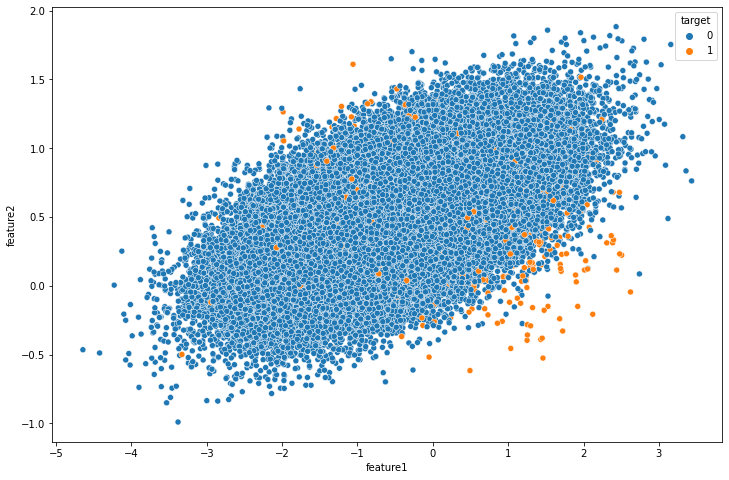

In [8]:
# Visualize the data
plt.figure(figsize=(12, 8))
sns.scatterplot(x = 'feature1', y = 'feature2', hue = 'target', data = df)

# Step 3: Train Test Split

In this step, we split the dataset into 80% training data and 20% validation data. `random_state` ensures that we have the same train test split every time. The seed number for `random_state` does not have to be 101, and it can be any number.

In [10]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)
print('The number of records in the training dataset is', X_train.shape[0])
print('The number of records in the test dataset is', X_test.shape[0])

The number of records in the training dataset is 80000
The number of records in the test dataset is 20000


The train test split gives us 80,000 records for the training dataset and 20,000 for the validation dataset. Thus, we have 79,156 data points from the majority class and 844 from the minority class in the training dataset.

In [11]:
# Check the number of majority and minority classes for the training dataset
print(sorted(Counter(y_train).items()))

[(0, 79156), (1, 844)]


# Step 4: Decide the Performance Metric

Before building the model, we need to decide the performance metric we would like to optimize towards.

The most critical performance metric for the rare events modeling is usually the minority class recall or precision values.
For example, in the context of fraud detection, we would like to maximize the true positive rate and capture as many fraud cases as possible, so recall for the minority class is the metric we would like to optimize.

While in the context of spam email classification, we would like to minimize the false positive rate and not misclassify any important email as spam, so the precision for the minority class is the metric we would like to optimize.

In this tutorial, we use fraud detection as an example and choose recall for the minority class as the metric to optimize.

# Step 5: Baseline Model

We first check the model performance using the imbalanced data directly. A model without oversampling or under-sampling gives us a baseline to compare the model performance. A random forest model is used as an example here.

In [13]:
# Train the random forest model
rf = RandomForestClassifier()
baseline_model = rf.fit(X_train, y_train)
baseline_prediction = baseline_model.predict(X_test)

# Check the model performance
print(classification_report(y_test, baseline_prediction))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     19814
           1       0.44      0.04      0.08       186

    accuracy                           0.99     20000
   macro avg       0.72      0.52      0.54     20000
weighted avg       0.99      0.99      0.99     20000



The recall value ranges from 0 to 1, 0 represents 0% true positive rate, and 1 represents 100% true positive rate. The output shows that the minority class has a recall of 0.04, which is very low. 

# Step 6: Random Over Sampling

One way of oversampling is to generate new samples for the minority class by sampling with replacement. The `RandomOverSampler` from the `imblearn` library provides such functionality.
Note that we apply the oversampling technique to the training dataset only. The testing dataset needs to keep untouched.

In [14]:
# Randomly over sample the minority class
ros = RandomOverSampler(random_state=101)
X_train_ros, y_train_ros= ros.fit_resample(X_train, y_train)

# Check the number of records after over sampling
print(sorted(Counter(y_train_ros).items()))

[(0, 79156), (1, 79156)]


After random oversampling, the minority category increased from 817 to 79156, which is the same as the majority category.

From the visualization, we can see more orange minority data points after random oversampling.

Text(0.5, 1.0, 'Random Over Sampling')

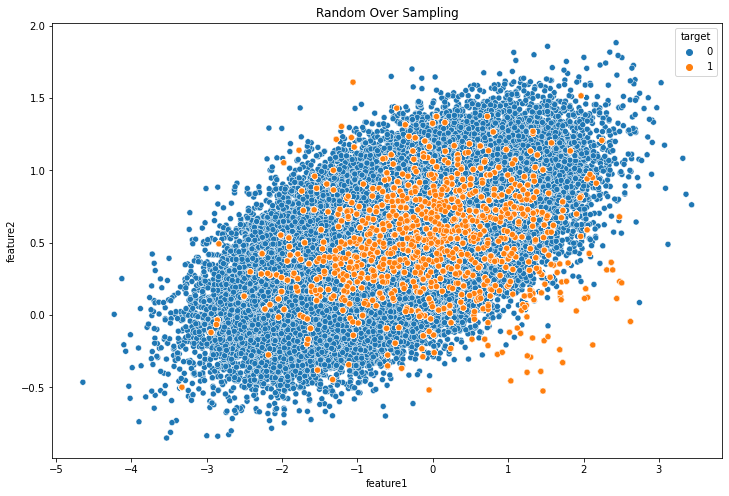

In [16]:
# Convert the data from numpy array to a pandas dataframe
df_ros = pd.DataFrame({'feature1': X_train_ros[:, 0], 'feature2': X_train_ros[:, 1], 'target': y_train_ros})

# Plot the chart
plt.figure(figsize=(12, 8))
sns.scatterplot(x = 'feature1', y = 'feature2', hue = 'target', data = df_ros)
plt.title('Random Over Sampling')

Now let's run the same random forest model and check the performance after random oversampling.

In [17]:
# Train the random forest model
# rf = RandomForestClassifier()
ros_model = rf.fit(X_train_ros, y_train_ros)
ros_prediction = ros_model.predict(X_test)

# Check the model performance
print(classification_report(y_test, ros_prediction))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     19814
           1       0.20      0.07      0.10       186

    accuracy                           0.99     20000
   macro avg       0.60      0.53      0.55     20000
weighted avg       0.98      0.99      0.99     20000



We can see that random oversampling did not provide a better result. We get similar recall and the similar f1-score, and the precision decreased. Thus, the random oversampling has worse performance than the baseline model with no class ratio adjustment.

# Step 7: SMOTE Oversampling

Let's try SMOTE (Synthetic Minority Oversampling Technique), published in 2002 by Chawla, Bowyer, Hall & Kegelmeyer [2]. Instead of randomly oversampling with replacement, SMOTE takes each minority sample and introduces synthetic data points connecting the minority sample and its nearest neighbors. Neighbors from the k nearest neighbors are chosen randomly.

In [18]:
# Randomly over sample the minority class
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote= smote.fit_resample(X_train, y_train)

# Check the number of records after over sampling
print(sorted(Counter(y_train_smote).items()))

[(0, 79156), (1, 79156)]


Similar to random oversampling, the minority category increased from 817 to 79156 after SMOTE oversampling.

Comparing the graph between random oversampling and SMOTE, we can see that the synthetic data points created by SMOTE are all along a line. 

Text(0.5, 1.0, 'SMOTE Over Sampling')

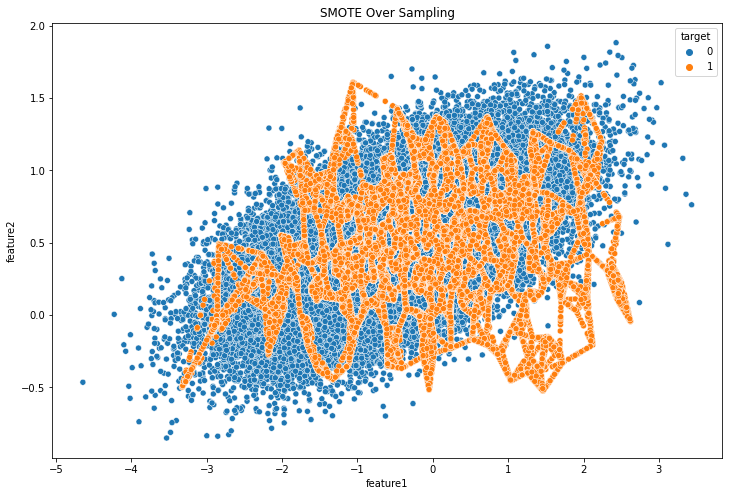

In [19]:
# Convert the data from numpy array to a pandas dataframe
df_smote = pd.DataFrame({'feature1': X_train_smote[:, 0], 'feature2': X_train_smote[:, 1], 'target': y_train_smote})

# Plot the chart
plt.figure(figsize=(12, 8))
sns.scatterplot(x = 'feature1', y = 'feature2', hue = 'target', data = df_smote)
plt.title('SMOTE Over Sampling')



Now let's run the same random forest model on the SMOTE dataset and check it's performance.

In [20]:
# Train the random forest model
# rf = RandomForestClassifier()
smote_model = rf.fit(X_train_smote, y_train_smote)
smote_prediction = smote_model.predict(X_test)

# Check the model performance
print(classification_report(y_test, smote_prediction))

              precision    recall  f1-score   support

           0       0.99      0.84      0.91     19814
           1       0.02      0.27      0.03       186

    accuracy                           0.83     20000
   macro avg       0.50      0.56      0.47     20000
weighted avg       0.98      0.83      0.90     20000



We can see that the model using SMOTE increased recall to 0.27. Thus, it significantly improved the model's ability to capture the minority class. 

# Step 8: Random Under-Samplling

Random under-sampling randomly picks data points from the majority class. After the sampling, the majority class has the same number of data points as the minority class.

In [21]:
# Randomly under sample the majority class
rus = RandomUnderSampler(random_state=101)
X_train_rus, y_train_rus= rus.fit_resample(X_train, y_train)

# Check the number of records after under sampling
print(sorted(Counter(y_train_rus).items()))

[(0, 844), (1, 844)]


After random under-sampling, the majority category decreased from 844, which is the same as the minority category.

The visualization shows that we have less data points for the model.

Text(0.5, 1.0, 'Random Under Sampling')

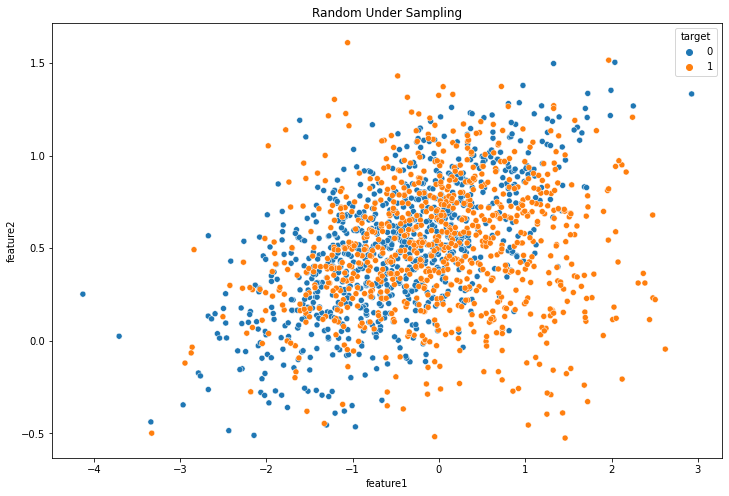

In [22]:
# Convert the data from numpy array to a pandas dataframe
df_rus = pd.DataFrame({'feature1': X_train_rus[:, 0], 'feature2': X_train_rus[:, 1], 'target': y_train_rus})

# Plot the chart
plt.figure(figsize=(12, 8))
sns.scatterplot(x = 'feature1', y = 'feature2', hue = 'target', data = df_rus)
plt.title('Random Under Sampling')

In [23]:
# Train the random forest model
# rf = RandomForestClassifier()
rus_model = rf.fit(X_train_rus, y_train_rus)
rus_prediction = rus_model.predict(X_test)

# Check the model performance
print(classification_report(y_test, rus_prediction))

              precision    recall  f1-score   support

           0       0.99      0.62      0.76     19814
           1       0.01      0.54      0.03       186

    accuracy                           0.61     20000
   macro avg       0.50      0.58      0.39     20000
weighted avg       0.98      0.61      0.75     20000



After randomly sampling, the recall increased to 0.54, and it's better than the over sampling results.

# Step 9: Under Sampling Using NearMiss

`NearMiss` from the `imblearn` library uses the KNN (K Nearest Neighbors) to do under sampling.

There are three versions of `NearMiss` algorithms. Based on the documentation of the `imblearn` library, here are the differences of the three versions:
* "NearMiss-1 selects the positive samples for which the average distance to the N closest samples of the negative class is the smallest."
* "NearMiss-2 selects the positive samples for which the average distance to the N farthest samples of the negative class is the smallest."
* "NearMiss-3 is a 2-steps algorithm. First, for each negative sample, their M nearest-neighbors will be kept. Then, the positive samples selected are the one for which the average distance to the N nearest-neighbors is the largest."

This tutorial uses version 3, but you are encouraged to try other versions and compare the performances.

In [24]:
# Under sample the majority class
nearmiss = NearMiss(version=3)
X_train_nearmiss, y_train_nearmiss= nearmiss.fit_resample(X_train, y_train)

# Check the number of records after over sampling
print(sorted(Counter(y_train_nearmiss).items()))

[(0, 844), (1, 844)]


The visualization shows the pattern of the NearMiss under-sampling.

Text(0.5, 1.0, 'NearMiss Under Sampling')

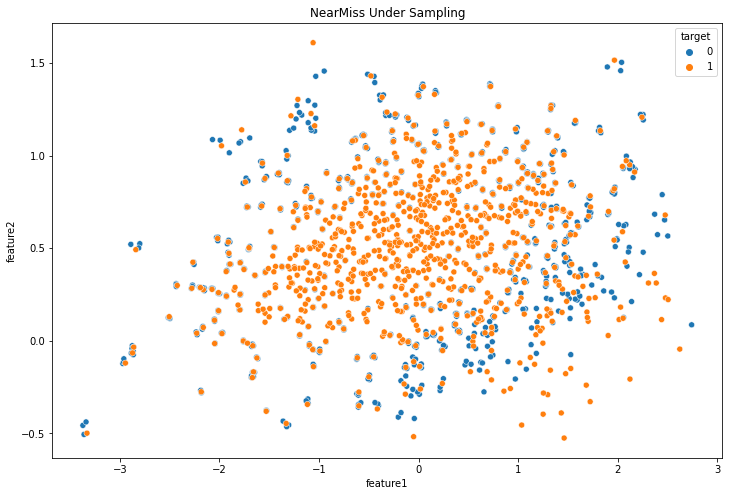

In [25]:
# Convert the data from numpy array to a pandas dataframe
df_nearmiss = pd.DataFrame({'feature1': X_train_nearmiss[:, 0], 'feature2': X_train_nearmiss[:, 1], 'target': y_train_nearmiss})

# Plot the chart
plt.figure(figsize=(12, 8))
sns.scatterplot(x = 'feature1', y = 'feature2', hue = 'target', data = df_nearmiss)
plt.title('NearMiss Under Sampling')

In [26]:
# Train the random forest model
# rf = RandomForestClassifier()
nearmiss_model = rf.fit(X_train_nearmiss, y_train_nearmiss)
nearmiss_prediction = nearmiss_model.predict(X_test)

# Check the model performance
print(classification_report(y_test, nearmiss_prediction))

              precision    recall  f1-score   support

           0       0.99      0.36      0.53     19814
           1       0.01      0.65      0.02       186

    accuracy                           0.36     20000
   macro avg       0.50      0.50      0.27     20000
weighted avg       0.98      0.36      0.52     20000



`NearMiss` gives us the recall values of 0.65, which is the highest among the four methods.

# References

* [1] [imbalanced learn documentation](https://imbalanced-learn.org/stable/install.html)
* [2] [SMOTE: Synthetic Minority Over-sampling Technique](https://arxiv.org/abs/1106.1813)
* [3] [NearMiss](https://www.scirp.org/(S(351jmbntvnsjt1aadkposzje))/reference/ReferencesPapers.aspx?ReferenceID=1603053)